# Multi-Agent LLM Portfolio Generator

This project builds an end-to-end pipeline of LLM agents that generates personalized ETF investment portfolios based on individual user profiles. The system uses the OpenAI Chat Completions API to coordinate three specialized agents — a market analyst, a risk assessor, and a portfolio constructor — which collaborate to analyze real market data and produce tailored recommendations.

**Pipeline:**
1. Data Collection (ETFs, market data, news sentiment)
2. User Profile Definition
3. Multi-Agent Portfolio Generation
4. Backtesting & Evaluation

---
## Setup & Imports

In [1]:
# Install required packages (run once)
# !pip install openai yfinance pandas numpy matplotlib seaborn

In [2]:
import os
import json
from datetime import datetime, timedelta
from typing import Dict, List, Tuple

# Data & Analysis
import pandas as pd
import numpy as np
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# LLM API
from openai import OpenAI

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# API Key Setup
# IMPORTANT: Do NOT hardcode your API key here!
# Set it as an environment variable: export OPENAI_API_KEY='your-key'

# In case you want to add key temporarily
# import os
# os.environ['OPENAI_API_KEY'] = "enter your key here in quotes"

# Test API connection
from openai import OpenAI
client = OpenAI()

response = client.responses.create(
    # Used gpt 5.2 for this assignment, can change the model
    model="gpt-5.2",
    # you can replace this with any prompt you'd like to test
    input="Hi I'm Raabiyaal, how are you?"
)

print(response.output_text)

Hi Raabiyaal! I’m doing well—thanks for asking. How are you today?


---
## Part 1: Data Collection & Preparation

Collecting two years of historical price data for 43 ETFs spanning 11 sectors, along with recent news headlines per ETF for sentiment analysis.

In [4]:
# Define ETF universe

ETF_UNIVERSE = {
    'Technology': ['XLK', 'VGT', 'QQQ', 'SMH'],
    'Healthcare': ['XLV', 'VHT', 'IBB', 'FHLC'],
    'Energy': ['XLE', 'VDE', 'IXC', 'AMLP'],
    'Financial': ['XLF', 'VFH', 'KBE', 'KBWB'],
    'Real Estate': ['VNQ', 'IYR', 'XLRE', 'SCHH'],
    'Consumer': ['XLY', 'VCR', 'XLP'],
    'Industrials': ['XLI', 'VIS', 'IYJ', 'ITA'],
    'Bonds': ['BND', 'AGG', 'TLT', 'SGOV'],
    'International': ['VXUS', 'VEA', 'VWO','BNDX','WTRE'],
    'ESG/Sustainable': ['ESGU', 'ESGV', 'SUSL','TAN'],
    'Artificial Intelligence': ['IYW', 'FTEC', 'IGM']
}

# Flatten to single list
all_etfs = [etf for sector_etfs in ETF_UNIVERSE.values() for etf in sector_etfs]
print(f"Total ETFs to analyze: {len(all_etfs)}")
print(f"Sectors covered: {list(ETF_UNIVERSE.keys())}")

Total ETFs to analyze: 43
Sectors covered: ['Technology', 'Healthcare', 'Energy', 'Financial', 'Real Estate', 'Consumer', 'Industrials', 'Bonds', 'International', 'ESG/Sustainable', 'Artificial Intelligence']


In [5]:
def fetch_etf_data(tickers: List[str], period: str = '2y') -> pd.DataFrame:
    """
    Fetch historical price data for given ETFs.
    
    Args:
        tickers: List of ETF ticker symbols
        period: Time period (e.g., '1y', '2y', '5y')
    
    Returns:
        DataFrame with adjusted close prices
    """
    data = yf.download(tickers, period=period)['Close']
    return data

# Fetch data
price_data = fetch_etf_data(all_etfs)
print(f"Data shape: {price_data.shape}")
print(f"Date range: {price_data.index.min()} to {price_data.index.max()}")
price_data.head()

[*********************100%***********************]  43 of 43 completed


Data shape: (501, 43)
Date range: 2024-03-12 00:00:00 to 2026-03-11 00:00:00


Ticker,AGG,AMLP,BND,BNDX,ESGU,ESGV,FHLC,FTEC,IBB,IGM,...,VXUS,WTRE,XLE,XLF,XLI,XLK,XLP,XLRE,XLV,XLY
Date,,,,,,,,,,,,,,,,,,,,,
2024-03-12,90.690269,39.754105,67.311859,45.009392,110.974396,90.323761,67.302452,155.855652,137.308212,86.447144,...,56.482567,17.214285,41.651283,39.675896,118.785194,104.142586,71.919136,37.232815,142.229950,89.165817
2024-03-13,90.523544,39.813721,67.200630,44.963501,110.778969,90.088783,67.156845,154.281769,137.527039,85.650581,...,56.398331,17.109552,42.316288,39.967201,119.105942,103.017365,72.099022,36.999344,141.678558,88.979012
2024-03-14,89.949280,39.336716,66.801971,44.807442,110.466301,89.755875,66.758820,153.707642,134.990585,85.142761,...,56.042686,16.871525,42.751812,39.646770,118.600517,103.037102,71.540413,36.476391,141.175552,88.413635
2024-03-15,89.939995,39.720028,66.764908,44.798260,109.684570,89.032516,66.542572,151.572205,135.199448,83.908096,...,55.980690,16.823919,42.878254,39.607925,118.619949,101.482513,71.512009,36.457714,140.614456,87.533630
2024-03-18,89.847404,39.805206,66.681488,44.798260,110.407646,89.533073,66.562057,152.335556,134.542938,84.824142,...,55.990078,16.747747,43.026485,39.835022,118.830551,101.981300,71.971718,36.452065,140.597961,88.202217


In [6]:
def calculate_etf_metrics(price_data: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate key metrics for each ETF.
    
    Metrics to calculate:
    - Total return
    - Historical returns
    - Volatility (std of returns)
    - Sharpe ratio (assuming risk-free rate of 3%)
    - Max drawdown
    - Max Loss
    - Average Daily Return
    - Annual Return
    - Sortino Ratio
    """
    # Assuming risk free rate of 3%
    rf = 0.03

    metrics = {}
    
    # Calculating daily returns for further calculations 
    daily_return = price_data.pct_change().dropna()
    for etf in price_data.columns:
        etf_return = daily_return[etf]
        etf_price = price_data[etf]
        # Total Return
        total_return = (etf_price.iloc[-1]/etf_price.iloc[0] - 1)
        # Volatility
        volatility = etf_return.std()*(252**0.5)
        # Sharpe
        sharpe = ((etf_return.mean()*252)-rf)/volatility
        # Max Drawdown
        cumulative = (1 + etf_return).cumprod()
        peak = cumulative.cummax()
        drawdown = (cumulative - peak) / peak
        max_drawdown = drawdown.min()
        # Max Loss 
        max_loss = etf_return.min()
        # Average Daily Return
        avg_return = etf_return.mean()
        # Annual Return
        annual_return = (1 + etf_return.mean())**252 - 1
        # Sortino Ratio
        negative_return = etf_return[etf_return < 0] 
        negative_volatility = negative_return.std()*(252**0.5)
        sortino = ((etf_return.mean()*252)-rf)/negative_volatility

        metrics[etf] = {"Total Return": total_return,
                        "Volatility": volatility,
                        "Sharpe Ratio": sharpe,
                        "Max Drawdown": max_drawdown,
                        "Max Loss": max_loss,
                        "Average Daily Return": avg_return,
                        "Annual Return": annual_return,
                        "Sortino Ratio":sortino}
  
    return pd.DataFrame(metrics).T

etf_metrics = calculate_etf_metrics(price_data)
etf_metrics.head(40)

,Total Return,Volatility,Sharpe Ratio,Max Drawdown,Max Loss,Average Daily Return,Annual Return,Sortino Ratio
AGG,0.098905,0.047826,0.390597,-0.048221,-0.012669,0.000193,0.049880,0.591808
AMLP,0.318354,0.154065,0.786951,-0.142667,-0.071118,0.000600,0.163225,1.013571
BND,0.097726,0.047206,0.383640,-0.047404,-0.012056,0.000191,0.049281,0.584487
BNDX,0.071998,0.033591,0.166892,-0.023484,-0.008109,0.000141,0.036245,0.250913
ESGU,0.325080,0.163272,0.766478,-0.193245,-0.059150,0.000616,0.167770,0.979488
ESGV,0.299769,0.171498,0.680965,-0.204053,-0.056259,0.000582,0.158055,0.883432
FHLC,0.084804,0.148062,0.148504,-0.168692,-0.054285,0.000206,0.053357,0.208047
FTEC,0.405724,0.254463,0.683097,-0.272991,-0.072326,0.000809,0.225980,0.908402
IBB,0.244427,0.206543,0.491742,-0.248510,-0.057683,0.000522,0.140574,0.705643
IGM,0.452101,0.244960,0.766883,-0.263858,-0.069840,0.000865,0.243291,1.017158


In [7]:
def get_etf_news(tickers: List[str]):
    """
    Get 5-10 news titles for each ETF.
    why do we use titles? 
    1. news summaries/articles are probs blocked by paywall
    2. news titles are v descriptive --> act like good header summaries
    
    Metrics to calculate:
    - Extract news titles from yfinance news output

    Returns:
        Data structure of choice that stores the ETF and corresponding news titles.
    """
    metrics = {}
    
    for ticker in tickers:
        etf = yf.Ticker(ticker)
        news = etf.news
        # print(news[0])
        titles = []
        # print(ticker, len(news))
        for item in news[:10]:
            if 'content' in item and 'title' in item['content']:
                titles.append(item['content']['title'])
        metrics[ticker] = titles  
    return pd.DataFrame.from_dict(metrics, orient="index")


etf_news = get_etf_news(all_etfs)
etf_news.head(10)

,0,1,2,3,4,5,6,7,8,9
XLK,Sector Update: Tech Stocks Advance Late Afternoon,Exchange-Traded Funds Drop as US Equities Fall...,"Exchange-Traded Funds, Equity Futures Lower Pr...",Exchange-Traded Funds Rise as US Equities Move...,The Surprising Vanguard ETF That Is Soaring Pa...,What Micron’s Stock Chart Says About the Possi...,Fidelity National Information Services Stock: ...,"Exchange-Traded Funds, Equity Futures Higher P...",'Make Tech Value Again': This is software's 'o...,Sector Update: Tech Stocks Gain Late Afternoon
VGT,"I’d Own VGT for the Next 30 Years, And Never L...",Budget iPhone 17e to Boost Apple Revenues? ETF...,Buy 3 Vanguard Index Funds to Beat the S&P 500...,Daily ETF Flows: VGT On Top,Looking to Buy the Dip on Tech Stocks? Conside...,ETFs to Buy as NVIDIA Shares Gain Following Q4...,"VGT, XLK, or QQQ: Which is the Best Tech ETF t...",Should You Invest in the Vanguard Information ...,"The Smartest Vanguard ETF to Buy With $2,000 R...",Buy 2 Vanguard Index Funds to Beat the S&P 500...
QQQ,Exchange-Traded Funds Drop as US Equities Fall...,CPI Keeps Steady at +2.4% YoY,Forget QQQ: 3 Sector ETFs Quietly Outperformin...,"Exchange-Traded Funds, Equity Futures Lower Pr...","I’d Own VGT for the Next 30 Years, And Never L...",AMAT and Micron still winning in AI trade desp...,Zacks Investment Ideas feature highlights Appl...,Bank Hapoalim Initiates $14.7 Million Position...,Exchange-Traded Funds Rise as US Equities Move...,Pre-Markets Take Cues from Spot Oil Prices
SMH,Semiconductor ETFs Rally with Bull 3X ETF up 1...,Should You Invest in the VanEck Semiconductor ...,ETFs to Buy as Broadcom Shares Jump 5% After Q...,The $650 Billion AI Surge Is Here—2 Semiconduc...,When Abundance Becomes Disruption: The AI Spen...,Nvidia Stock Falls Again. Why It’s Still Under...,"MoneyMasters Podcast 2-27-26- Finding Your ""Pe...",Is This the Reason Nvidia Lost 5% Today?,ETFs to Buy as NVIDIA Shares Gain Following Q4...,How to play options amid AI-induced market vol...
XLV,Sector Update: Health Care Stocks Lower Late A...,Biogen Stock: Is BIIB Outperforming the Health...,"Stock Market News for Mar 11, 2026","Exchange-Traded Funds, Equity Futures Lower Pr...",Sector Update: Health Care Stocks Decline Late...,Sector Update: Health Care Stocks Mixed Tuesda...,"Stock Market News for Mar 10, 2026","Exchange-Traded Funds, Equity Futures Higher P...",Sector Update: Health Care Stocks Higher Late ...,Sector Update: Health Care Stocks Softer Monda...
VHT,"Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Higher P...",ETFs to Play as Oil Surges Past $110 on Middle...,"Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Higher P...","Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Lower Pr..."
IBB,Josh Brown: Biotech growth stocks immune to di...,"Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Higher P...",Sector Update: Health Care Stocks Decline Prem...,"Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Higher P...","Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Lower Pr..."
FHLC,Should You Invest in the Fidelity MSCI Health ...,10 Fidelity ETFs With The Lowest Expense Ratio...,Is Fidelity’s Health Care ETF A Good Buy Right...,UnitedHealth Lifts EPS Outlook Despite Mixed Q...,ETFs to Watch Post JNJ's Q3 Earnings Surprise ...,None,None,None,None,None
XLE,USO vs. XLE: Which energy ETF do you play amid...,Sector Update: Energy Stocks Higher Late After...,Sector Update: Energy,Sector Update: Energy Stocks Rise Wednesday Af...,Why These Energy ETFs Are D

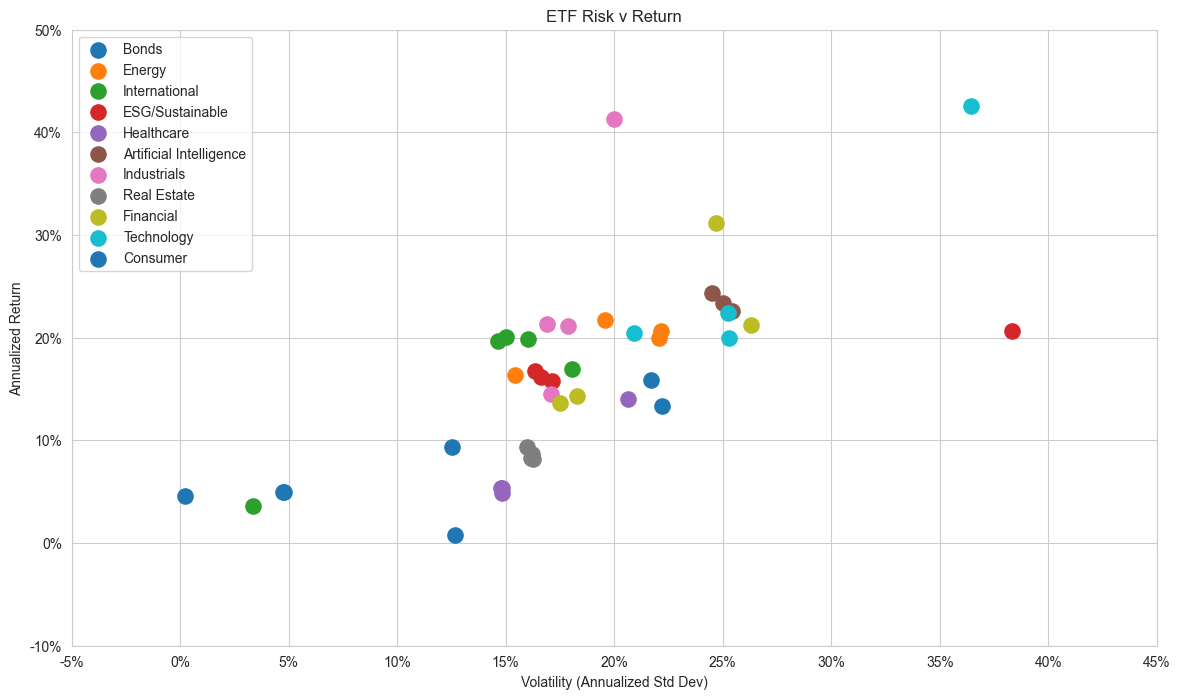

In [8]:
# Visualize ETF characteristics
plt.figure(figsize=(14, 8))

sector_map = {}
for sector, etfs in ETF_UNIVERSE.items():
    for etf in etfs:
        sector_map[etf] = sector

etf_metrics['Sector'] = etf_metrics.index.map(sector_map)
for sector in etf_metrics['Sector'].unique():

    subset = etf_metrics[etf_metrics['Sector'] == sector]

    plt.scatter(
        subset['Volatility'],
        subset['Annual Return'],
        label=sector,
        s=120
    )

plt.title('ETF Risk v Return')
plt.xlabel('Volatility (Annualized Std Dev)')
plt.ylabel('Annualized Return')
plt.xticks(plt.xticks()[0], [f'{x:.0%}' for x in plt.xticks()[0]])
plt.yticks(plt.yticks()[0], [f'{y:.0%}' for y in plt.yticks()[0]])
plt.legend(loc='upper left')
plt.show()

---
## Part 2: User Profile Collection

Defining structured user profiles to test the pipeline across different risk tolerances, investment horizons, and financial goals.

In [9]:
# Define user profile structure
USER_PROFILES = {
    'young_aggressive': {
        'name': 'Alex (Young Professional)',
        'age': 28,
        'investment_amount': 5000,
        'investment_horizon': '30+ years',
        'risk_tolerance': 'aggressive',
        'interests': ['technology', 'innovation', 'growth'],
        'goals': 'long-term wealth accumulation',
        'income_stability': 'high',
        'existing_portfolio': None
    },
    
    'middle_moderate': {
        'name': 'Jamie (Mid-Career)',
        'age': 45,
        'investment_amount': 10000,
        'investment_horizon': '15-20 years',
        'risk_tolerance': 'moderate',
        'interests': ['balanced growth', 'sustainability', 'dividend income'],
        'goals': 'retirement preparation with some growth',
        'income_stability': 'moderate',
        'existing_portfolio': 'some stocks and bonds'
    },

    'near_retirement_conservative': {
        'name': 'Richie (Near Retirement)',
        'age': 60,
        'investment_amount': 200000,
        'investment_horizon': '5-10 years',
        'risk_tolerance': 'conservative',
        'interests': ['income stability', 'bonds', 'dividend stocks'],
        'goals': 'preserve capital and generate steady income',
        'income_stability': 'stable',
        'existing_portfolio': 'diversified portfolio with bonds and blue-chip stocks'
    },

    'student_beginner': {
        'name': 'Raabiyaal (Graduate Student)',
        'age': 24,
        'investment_amount': 200,
        'investment_horizon': '25+ years',
        'risk_tolerance': 'moderate',
        'interests': ['crypto', 'technology', 'low-cost investing'],
        'goals': 'start investing early and build long-term wealth',
        'income_stability': 'low',
        'existing_portfolio': 'small ETF portfolio'
    }
}

# Display profiles
for profile_id, profile in USER_PROFILES.items():
    print(f"\n{'='*60}")
    print(f"Profile: {profile['name']}")
    print(f"{'='*60}")
    for key, value in profile.items():
        if key != 'name':
            print(f"  {key}: {value}")


Profile: Alex (Young Professional)
  age: 28
  investment_amount: 5000
  investment_horizon: 30+ years
  risk_tolerance: aggressive
  interests: ['technology', 'innovation', 'growth']
  goals: long-term wealth accumulation
  income_stability: high
  existing_portfolio: None

Profile: Jamie (Mid-Career)
  age: 45
  investment_amount: 10000
  investment_horizon: 15-20 years
  risk_tolerance: moderate
  interests: ['balanced growth', 'sustainability', 'dividend income']
  goals: retirement preparation with some growth
  income_stability: moderate
  existing_portfolio: some stocks and bonds

Profile: Richie (Near Retirement)
  age: 60
  investment_amount: 200000
  investment_horizon: 5-10 years
  risk_tolerance: conservative
  interests: ['income stability', 'bonds', 'dividend stocks']
  goals: preserve capital and generate steady income
  income_stability: stable
  existing_portfolio: diversified portfolio with bonds and blue-chip stocks

Profile: Raabiyaal (Graduate Student)
  age: 24
 

---
## Part 3: Multi-Agent LLM Pipeline

Building three specialized agents that each handle a distinct role — market analysis, risk assessment, and portfolio construction — and pass their outputs down the chain.

In [10]:
def call_llm(messages: List[Dict], model: str = "gpt-4.1-mini", temperature: float = 0.7) -> str:
    """
    Helper function to call OpenAI API.
    
    Args:
        messages: List of message dicts with 'role' and 'content'
        model: Model name
        temperature: Sampling temperature
    
    Returns:
        Response content as string

        Also look at the parameters used in the API call (model, temperature, max_tokens).
        You can experiment with different models and parameter settings to see how it affects the output. 
    """
    try:
        response = client.chat.completions.create(
            model=model,
            messages=messages,
            temperature=temperature,
            max_completion_tokens=1000
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"Error calling LLM: {e}")
        return None
    


### Agent 1: Market Analyst

In [11]:
def market_analyst_agent(etf_metrics: pd.DataFrame, sector_data: Dict) -> str:
    """
    Analyzes current market trends and sector performance.
    
    
    Prompt should:
    - Give the agent a clear role as a market analyst
    - Provide relevant market data (top/bottom peroformers, sector trends, news, use the Part 1 functions)
    - Ask for structured output (sector recommendations, utlook)
    - Encourage data-driven analysis
    
    Returns:
        Market analysis report as string
    """

    top_returns = etf_metrics.sort_values('Annual Return', ascending=False).head(5)
    worst_returns = etf_metrics.sort_values('Annual Return').head(5)
    low_vol = etf_metrics.sort_values('Volatility').head(5)
    high_vol = etf_metrics.sort_values('Volatility',ascending=False).head(5)
    
    # Prepare market data summary
    
    
    system_prompt = """
    You are a professional financial analyst.
    Provide data-driven insights about ETF sector performance.
    Use clear and structured analysis.
    """
    
    user_prompt = f"""
    I've shared with you the top 5 etfs in regards to: Annual Return {top_returns}, 
    Worst Returns {worst_returns}, Low Volatility {low_vol}, High Volatility {high_vol}. 
    Analyze which ETFs should an investor with low risk invest in
    """
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    return call_llm(messages)

# Test the agent
market_analysis = market_analyst_agent(etf_metrics, ETF_UNIVERSE)
print("\n=== MARKET ANALYST OUTPUT ===")
print(market_analysis)


=== MARKET ANALYST OUTPUT ===
### Analysis for Low-Risk Investor: ETF Selection

For a low-risk investor, the key considerations are:
- **Low Volatility**: To minimize price fluctuations.
- **Positive Sharpe and Sortino Ratios**: To ensure returns are favorable relative to risk.
- **Moderate to positive Total and Annual Returns**: To achieve growth without excessive risk.
- **Minimal Max Drawdown and Max Loss**: To limit potential capital losses.

---

### Relevant ETFs from Provided Data:

#### 1. **Low Volatility ETFs**
| ETF | Sector      | Total Return | Volatility | Sharpe Ratio | Max Drawdown | Max Loss | Annual Return | Sortino Ratio |
|------|-------------|--------------|------------|--------------|--------------|----------|---------------|---------------|
| SGOV | Bonds       | 0.002169     | 0.002169   | 6.921711     | -0.0001      | -0.0001  | 0.046040      | 6690.97       |
| BNDX | International Bonds | 0.033591     | 0.166892   | -0.023484    | -0.008109    | -0.0081  | 

### Agent 2: Risk Assessment Agent

In [12]:
def risk_assessment_agent(user_profile: Dict) -> str:
    """
    Assesses user risk tolerance and provides allocation guidelines.
    
    
    Prompt should:
    - Position agent as a financial advisor/risk specialist
    - Take user profile as input
    - Output risk assessment and allocation guidelines (% stocks, bonds, etc.)
    - Consider age, horizon, risk tolerance, goals
    
    Returns:
        Risk assessment report as string
    """
    
    

    system_prompt = """
     You are a financial advisor who helps investors understand their risk level
    and suggests simple asset allocation strategies.
    Keep the explanation clear and practical.    
    """
    
    user_prompt = f"""
    Here is an investor profile:

    {user_profile}

    Based on this profile:
    Assess their risk level, Suggest a simple asset allocation (% stocks, % bonds, % other) and 
    Briefly explain why this allocation fits them.
    """
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    
    return call_llm(messages)

# Test the agent, change the user profile to test different outputs
risk_assessment = risk_assessment_agent(USER_PROFILES['young_aggressive'])
risk_assessment2 = risk_assessment_agent(USER_PROFILES['student_beginner'])
print("\n=== RISK ASSESSMENT OUTPUT ===")
print(risk_assessment)
print("\n=== RISK ASSESSMENT OUTPUT 2 ===")
print(risk_assessment2)



=== RISK ASSESSMENT OUTPUT ===
Alex is young (28) with a long investment horizon (30+ years) and an aggressive risk tolerance. This means they can handle higher volatility for the potential of greater long-term returns. Their high income stability supports taking more risk, and their interest in technology and innovation aligns with growth-oriented investments.

**Suggested Asset Allocation:**
- Stocks: 85%
- Bonds: 10%
- Other (e.g., alternatives, cash): 5%

**Explanation:**
With 85% in stocks, Alex can focus on growth sectors like technology and innovation, which suit their interests and long-term wealth goals. The 10% in bonds provides some stability and reduces overall portfolio risk slightly without limiting growth potential much. The 5% in other assets or cash offers liquidity and diversification. This allocation balances aggressive growth with a small buffer, fitting Alex’s profile well.

=== RISK ASSESSMENT OUTPUT 2 ===
Hi Raabiyaal! Based on your profile, here’s an assessment

### Agent 3: Portfolio Construction Agent

In [13]:
def portfolio_construction_agent(
    user_profile: Dict,
    market_analysis: str,
    risk_assessment: str,
    available_etfs: Dict[str, List[str]]
) -> str:
    """
    Creates final portfolio recommendations based on all inputs.
    
    
    Prompt should:
    - Position agent as portfolio manager
    - Synthesize inputs from previous agents
    - Output specific ETF recommendations with allocation %
    - Ensure allocations sum to 100%
    - Consider asking for JSON output for easier parsing
    
    Returns:
        Portfolio recommendations (ideally as JSON string)
    """
    
    
    system_prompt = """
    You are a portfolio manager who builds ETF portfolios for investors.
    Use the investor profile, market analysis, and risk assessment to
    recommend a simple ETF portfolio.
    Ensure allocations add up to 100%.
    """

    user_prompt = f"""
    Investor profile:
    {user_profile}

    Market analysis:
    {market_analysis}

    Risk assessment:
    {risk_assessment}

    Available ETFs by sector:
    {available_etfs}

    Create a portfolio recommendation:
    - Select suitable ETFs
    - Assign allocation percentages
    - Ensure total allocation = 100%

    Return the result as JSON with ETF tickers and allocation percentages.
    """

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    return call_llm(messages)

# Test the agent
portfolio_recommendation = portfolio_construction_agent(
    USER_PROFILES['young_aggressive'],
    market_analysis,
    risk_assessment,
    ETF_UNIVERSE
)
print("\n=== PORTFOLIO CONSTRUCTION OUTPUT ===")
print(portfolio_recommendation)


=== PORTFOLIO CONSTRUCTION OUTPUT ===
```json
{
  "XLK": 35,
  "QQQ": 20,
  "FTEC": 10,
  "IYW": 10,
  "BND": 6,
  "AGG": 4,
  "SGOV": 3,
  "VXUS": 7,
  "XLP": 5
}
```


### Complete Pipeline

In [14]:
def generate_portfolio(user_profile: Dict, etf_metrics: pd.DataFrame) -> Dict:
    """
    Complete pipeline to generate a portfolio for a user.
    """
    print(f"\nGenerating portfolio for: {user_profile['name']}")
    print("="*60)

    # Step 1: Market Analysis
    print("\n[1/3] Running Market Analyst...")
    market_analysis = market_analyst_agent(etf_metrics, ETF_UNIVERSE)

    # Step 2: Risk Assessment
    print("[2/3] Running Risk Assessment...")
    risk_assessment = risk_assessment_agent(user_profile)

    # Step 3: Portfolio Construction
    print("[3/3] Running Portfolio Construction...")
    portfolio = portfolio_construction_agent(
        user_profile, market_analysis, risk_assessment, ETF_UNIVERSE
    )

    print("\n✓ Portfolio generation complete!")

    return {
        'user_profile': user_profile,
        'market_analysis': market_analysis,
        'risk_assessment': risk_assessment,
        'portfolio': portfolio
    }


def display_portfolio_result(result: Dict):
    """Pretty-print a portfolio generation result."""
    profile = result['user_profile']
    sep = "=" * 65

    print(sep)
    print(f"  PORTFOLIO REPORT: {profile['name'].upper()}")
    print(sep)

    # ── Profile summary ──────────────────────────────────────────────
    print("\n📋 INVESTOR PROFILE")
    print("-" * 40)
    fields = [
        ("Age",               profile['age']),
        ("Investment Amount", f"${profile['investment_amount']:,}"),
        ("Horizon",           profile['investment_horizon']),
        ("Risk Tolerance",    profile['risk_tolerance'].capitalize()),
        ("Goals",             profile['goals']),
        ("Interests",         ", ".join(profile['interests'])),
    ]
    for label, value in fields:
        print(f"  {label:<20} {value}")

    # ── Risk assessment ───────────────────────────────────────────────
    print("\n📊 RISK ASSESSMENT")
    print("-" * 40)
    for line in result['risk_assessment'].splitlines():
        print(f"  {line}")

    # ── Portfolio allocation ──────────────────────────────────────────
    print("\n💼 PORTFOLIO ALLOCATION")
    print("-" * 40)
    raw = result['portfolio']
    # Strip markdown code fences if present
    import re
    json_match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', raw, re.DOTALL)
    if json_match:
        try:
            port_json = json.loads(json_match.group(1))
            # Flatten nested dict if needed
            allocations = {}
            for k, v in port_json.items():
                if isinstance(v, dict):
                    for ticker, pct in v.items():
                        allocations[ticker] = pct
                else:
                    allocations[k] = v
            print(f"  {'ETF/Asset':<30} {'Allocation':>10}")
            print(f"  {'-'*30} {'-'*10}")
            for ticker, pct in allocations.items():
                bar = "█" * int(pct // 5)
                print(f"  {ticker:<30} {str(pct)+'%':>8}  {bar}")
            total = sum(v for v in allocations.values() if isinstance(v, (int, float)))
            print(f"  {'-'*30} {'-'*10}")
            print(f"  {'TOTAL':<30} {str(total)+'%':>8}")
        except Exception:
            print(raw)
    else:
        print(raw)

    print()


# ── Run pipeline on both profiles ────────────────────────────────────
result_alex   = generate_portfolio(USER_PROFILES['young_aggressive'],            etf_metrics)
result_richie = generate_portfolio(USER_PROFILES['near_retirement_conservative'], etf_metrics)

display_portfolio_result(result_alex)
display_portfolio_result(result_richie)



Generating portfolio for: Alex (Young Professional)

[1/3] Running Market Analyst...
[2/3] Running Risk Assessment...
[3/3] Running Portfolio Construction...

✓ Portfolio generation complete!

Generating portfolio for: Richie (Near Retirement)

[1/3] Running Market Analyst...
[2/3] Running Risk Assessment...
[3/3] Running Portfolio Construction...

✓ Portfolio generation complete!
  PORTFOLIO REPORT: ALEX (YOUNG PROFESSIONAL)

📋 INVESTOR PROFILE
----------------------------------------
  Age                  28
  Investment Amount    $5,000
  Horizon              30+ years
  Risk Tolerance       Aggressive
  Goals                long-term wealth accumulation
  Interests            technology, innovation, growth

📊 RISK ASSESSMENT
----------------------------------------
  Alex is young (28) with a long investment horizon (30+ years) and an aggressive risk tolerance. This means Alex can comfortably withstand market ups and downs to pursue higher long-term returns. With high income stab

## Project Summary

This notebook builds a multi-agent LLM pipeline for personalized ETF portfolio generation. The project combines financial data, investor profiles, and sequential agents to generate portfolio allocations tailored to different types of investors.

**Part 1 – Data Collection & Preparation**  
Historical price data for 43 ETFs across 11 sectors (Technology, Healthcare, Energy, Financials, Real Estate, Consumer, Industrials, Bonds, International, ESG, and AI) was collected using `yfinance`. Two years of daily prices were used to compute key performance metrics for each ETF, including total return, annualized volatility, Sharpe ratio, Sortino ratio, maximum drawdown, and average daily return. Recent news headlines for each ETF were also retrieved to allow the model to incorporate sentiment signals. A risk-return scatter plot was created to visualize how ETFs cluster by sector. Technology and Industrials appear in the higher risk and return range, while Bonds and Real Estate fall on the more conservative side.

**Part 2 – User Profiles**  
Four investor profiles were created to test the pipeline across different life stages and risk preferences: Alex (28, aggressive, tech-focused), Jamie (45, moderate, sustainability-oriented), Richie (60, conservative, income-focused), and Raabiyaal (24, moderate, low-cost ETFs). Each profile includes age, investment amount, time horizon, risk tolerance, financial goals, and existing portfolio context. These attributes are passed directly into the agents to guide their decisions.

**Part 3 – Multi-Agent Pipeline**  
Three LLM agents perform separate tasks in the portfolio generation process:

- **Market Analyst Agent** analyzes the ETF metrics dataframe and identifies top and bottom performers, sector trends, and volatility patterns. It produces a structured market analysis summary.
- **Risk Assessment Agent** evaluates the user profile to determine an appropriate risk level and target asset allocation across stocks, bonds, and other assets. It also generates a plain-language explanation tailored to the investor.
- **Portfolio Construction Agent** combines the market analysis and risk assessment with the ETF universe to produce a final portfolio allocation in JSON format. Each ticker receives a percentage weight and the allocations sum to 100%.

The `generate_portfolio()` function connects the agents sequentially, passing outputs from one stage to the next. It returns a complete portfolio recommendation for each investor profile. Test runs with Alex (aggressive, long investment horizon) and Richie (conservative, near retirement) produced clearly different portfolios. Alex's portfolio concentrated on growth-oriented equity ETFs, while Richie's portfolio emphasized bond ETFs and capital preservation.